In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

from collections import namedtuple
from typing import Callable
ScalarFunc = Callable[[float], float]
import sys
eps = sys.float_info.epsilon

# Численное интегрирование

### Реализация методов Ньютона-Котеса

In [3]:
def integrate_left_rectangles(f: ScalarFunc, a: float, b: float, n=1) -> float:
  """ Метод левых прямоугольников """
  h = (b - a) / n
  return h * sum(f(a + h * i) for i in range(0, n))

def integrate_right_rectangles(f: ScalarFunc, a: float, b: float, n=1) -> float:
  """ Метод правых прямоугольников """
  h = (b - a) / n
  return h * sum(f(a + h * i) for i in range(1, n + 1))

def integrate_mid_rectangles(f: ScalarFunc, a: float, b: float, n=1) -> float:
  """ Метод средних прямоугольников """
  h = (b - a) / n
  return h * sum(f(a + h * i + h / 2) for i in range(0, n))

def integrate_trapezoidal(f: ScalarFunc, a: float, b: float, n=1) -> float:
  """ Метод трапеций """
  h = (b - a) / n
  return h * ((f(a) + f(b))/2 + sum(f(a + h * i) for i in range(1, n)))

def integrate_simpson(f: ScalarFunc, a: float, b: float, k=1) -> float:
  """ Метод Симпсона """
  n = 2 * k
  h = (b - a) / n
  s = f(a) + f(b)
  s += 2 * sum(f(a + i * h) for i in range(2, n, 2))
  s += 4 * sum(f(a + i * h) for i in range(1, n, 2))
  return h / 3 * s

def integrate_method_38(f: ScalarFunc, a: float, b: float, k=1) -> float:
  """ Метод 3/8 """
  n = 3 * k
  h = (b - a) / n
  s = f(a) + f(b)
  s += 3 * sum(f(a + h*i) for i in range(1, n) if i % 3 != 0)
  s += 2 * sum(f(a + h*i) for i in range(3, n, 3))
  return 0.375 * h * s

In [4]:
# Теоретическая верхняя граница ошибок методов
err_left_rectangles  = lambda a, b, h, M: (b - a) / 2   * h    * M[1]
err_right_rectangles = lambda a, b, h, M: (b - a) / 2   * h    * M[1]
err_mid_rectangles   = lambda a, b, h, M: (b - a) / 24  * h**2 * M[2]
err_trapezoidal      = lambda a, b, h, M: (b - a) / 12  * h**2 * M[2]
err_simpson          = lambda a, b, h, M: (b - a) / 180 * h**4 * M[4]
err_method_38        = lambda a, b, h, M: (b - a) / 80  * h**4 * M[4]

In [5]:
Method = namedtuple('Method' , 'title integrate dh error color')
methods = [
  Method("Метод левых",    integrate_left_rectangles,  1, err_left_rectangles,  "tab:blue"),
  Method("Метод правых",   integrate_right_rectangles, 1, err_right_rectangles, "tab:orange"),
  Method("Метод средних",  integrate_mid_rectangles,   1, err_mid_rectangles,   "tab:green"),
  Method("Метод трапеций", integrate_trapezoidal,      1, err_trapezoidal,      "tab:red"),
  Method("Метод Симпсона", integrate_simpson,          2, err_simpson,          "tab:purple"),
  Method("Метод 3/8",      integrate_method_38,        3, err_method_38,        "tab:brown")
]

### Простой тест работоспособности

In [6]:
def test_simple(f: ScalarFunc, F: ScalarFunc, a: float, b: float, n=1):
  """ Проверка всех методов на конкретной ситуации """
  correct = F(b) - F(a)
  print(f"Истинное значение {correct}")
  print(f"Шаг {(b - a) / n:.3f}")
  for m in methods:
    val = m.integrate(f, a, b, (n+m.dh-1)//m.dh)
    print(f"{m.title}:\t{val:.10f}\t({abs((correct-val)/correct*100):.8f}%)")

### Тест зависимости err(h)

In [7]:
def test_h(title: str, f: ScalarFunc, F: ScalarFunc, a: float, b: float, M, n_axis):
  """ Зависимость ошибки от шага h
    f - функция, [a, b] - границы интегрирования
    F - неопределённый интеграл с const=0
    M - список sup производных i-ого порядка
    n_axis - итерируемый объект с необходимыми n
  """
  plt.figure(figsize=(9, 6))
  truly = F(b) - F(a)  # Истинное значение
  h_axis = [(b - a) / n for n in n_axis]

  for m in methods:
    # Фактическая ошибка
    err_axis = []
    for n in n_axis:
      Fx = m.integrate(f, a, b, (n + m.dh - 1) // m.dh)
      err = abs(truly - Fx)
      err_axis.append(err)
    plt.plot(h_axis, err_axis, label=m.title, color=m.color)
    # Теоретическая ошибка
    theory = [m.error(a, b, h, M) for h in h_axis]
    plt.plot(h_axis, theory, '--', alpha=0.7, label=f"теор. sup ошибки", color=m.color)

  plt.axhline(eps, color='black', label="machine ε")

  plt.xscale('log')
  plt.yscale('log')
  plt.xlabel("h (log)")
  plt.ylabel("Ошибка (log)")
  plt.title(f"Err(h) для {title} на [{a}, {b}]")
  plt.legend()
  plt.grid(True, which="both", ls="--")
  plt.show()

### $f(x) = x^n$

###### Тестовые запуски для разных степеней

In [8]:
a, b, n = 1, 3, 100

In [9]:
print("f(x) = 1")
test_simple(f = lambda x: 1, F = lambda x: x, a=a, b=b, n=n)
print("f(x) = x")
test_simple(f = lambda x: x, F = lambda x: x**2/2, a=a, b=b, n=n)
print("f(x) = x²")
test_simple(f = lambda x: x**2, F = lambda x: x**3/3, a=a, b=b, n=n)
print("f(x) = x³")
test_simple(f = lambda x: x**3, F = lambda x: x**4/4, a=a, b=b, n=n)
print("f(x) = x⁴")
test_simple(f = lambda x: x**4, F = lambda x: x**5/5, a=a, b=b, n=n)
print("f(x) = x⁵")
test_simple(f = lambda x: x**5, F = lambda x: x**6/6, a=a, b=b, n=n)

f(x) = 1
Истинное значение 2
Шаг 0.020
Метод левых:	2.0000000000	(0.00000000%)
Метод правых:	2.0000000000	(0.00000000%)
Метод средних:	2.0000000000	(0.00000000%)
Метод трапеций:	2.0000000000	(0.00000000%)
Метод Симпсона:	2.0000000000	(0.00000000%)
Метод 3/8:	2.0000000000	(0.00000000%)
f(x) = x
Истинное значение 4.0
Шаг 0.020
Метод левых:	3.9800000000	(0.50000000%)
Метод правых:	4.0200000000	(0.50000000%)
Метод средних:	4.0000000000	(0.00000000%)
Метод трапеций:	4.0000000000	(0.00000000%)
Метод Симпсона:	4.0000000000	(0.00000000%)
Метод 3/8:	4.0000000000	(0.00000000%)
f(x) = x²
Истинное значение 8.666666666666666
Шаг 0.020
Метод левых:	8.5868000000	(0.92153846%)
Метод правых:	8.7468000000	(0.92461538%)
Метод средних:	8.6666000000	(0.00076923%)
Метод трапеций:	8.6668000000	(0.00153846%)
Метод Симпсона:	8.6666666667	(0.00000000%)
Метод 3/8:	8.6666666667	(0.00000000%)
f(x) = x³
Истинное значение 20.0
Шаг 0.020
Метод левых:	19.7408000000	(1.29600000%)
Метод правых:	20.2608000000	(1.30400000

In [10]:
print("f(x) = 1/x")
test_simple(f = lambda x: 1/x, F = lambda x: math.log(x), a=a, b=b, n=n)
print("f(x) = 1/x²")
test_simple(f = lambda x: x**(-2), F = lambda x: x**(-1) / (-1), a=a, b=b, n=n)
print("f(x) = 1/x³")
test_simple(f = lambda x: x**(-3), F = lambda x: x**(-2) / (-2), a=a, b=b, n=n)
print("f(x) = 1/x⁴")
test_simple(f = lambda x: x**(-4), F = lambda x: x**(-3) / (-3), a=a, b=b, n=n)
print("f(x) = 1/x⁵")
test_simple(f = lambda x: x**(-5), F = lambda x: x**(-4) / (-4), a=a, b=b, n=n)

f(x) = 1/x
Истинное значение 1.0986122886681098
Шаг 0.020
Метод левых:	1.1053085836	(0.60952304%)
Метод правых:	1.0919752503	(0.60412927%)
Метод средних:	1.0985974750	(0.00134840%)
Метод трапеций:	1.0986419170	(0.00269689%)
Метод Симпсона:	1.0986122939	(0.00000048%)
Метод 3/8:	1.0986122996	(0.00000099%)
f(x) = 1/x²
Истинное значение 0.6666666666666667
Шаг 0.020
Метод левых:	0.6756197478	(1.34296217%)
Метод правых:	0.6578419700	(1.32370450%)
Метод средних:	0.6666345725	(0.00481412%)
Метод трапеций:	0.6667308589	(0.00962883%)
Метод Симпсона:	0.6666666879	(0.00000318%)
Метод 3/8:	0.6666667107	(0.00000661%)
f(x) = 1/x³
Истинное значение 0.4444444444444444
Шаг 0.020
Метод левых:	0.4541728262	(2.18888589%)
Метод правых:	0.4349135669	(2.14444744%)
Метод средних:	0.4443950734	(0.01110849%)
Метод трапеций:	0.4445431966	(0.02221923%)
Метод Симпсона:	0.4444444976	(0.00001196%)
Метод 3/8:	0.4444445547	(0.00002481%)
f(x) = 1/x⁴
Истинное значение 0.32098765432098764
Шаг 0.020
Метод левых:	0.33099695

##### $f(x) = x$

Есть ошибка только у левых и правых многоугольников, так как функция монотонно возрастает: левая всегда берёт меньше, а правая всегда больше. Метод средних прямоугольников не даёт ошибок, так как точная площадь под линейной функцией на этом отрезке равна высоте в точности в середине. По методу трапеций получается с точностью трапеция.

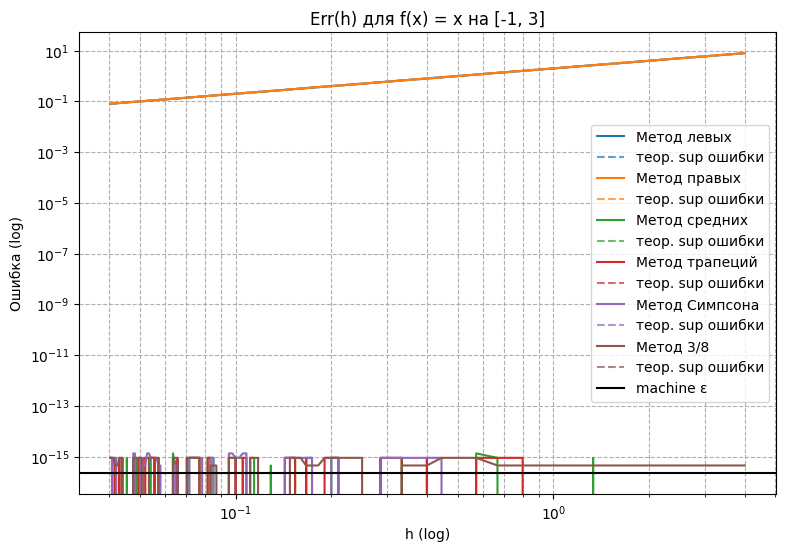

In [11]:
test_h(
  title = "f(x) = x",
  f = lambda x: x,
  F = lambda x: x**2/2,
  a = -1,
  b = 3,
  M = {1: 1, 2: 0, 4: 0},
  n_axis = range(1, 100, 1)
)

##### $f(x) = x^2$

Метод симпсона и 3/8 с точностью описывают квадратную функцию. Остальные же просто приближают её линейными.

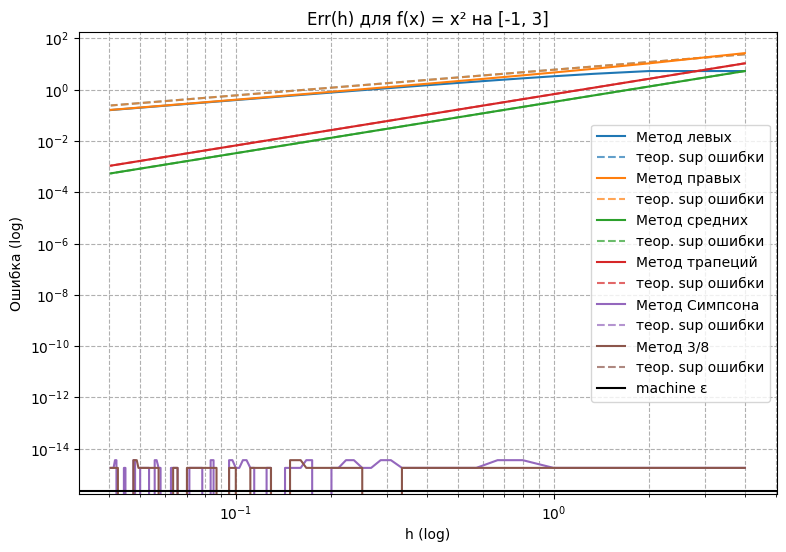

In [12]:
test_h(
  title = "f(x) = x²",
  f = lambda x: x**2,
  F = lambda x: x**3/3,
  a = -1,
  b = 3,
  M = {1: 3, 2: 2, 4: 0},
  n_axis = range(1, 100, 1)
)

##### $f(x) = x^5$

При увеличении степеней погрешность всех методов увеличивается. Из-интересного: график ошибки от h начинает колебаться.

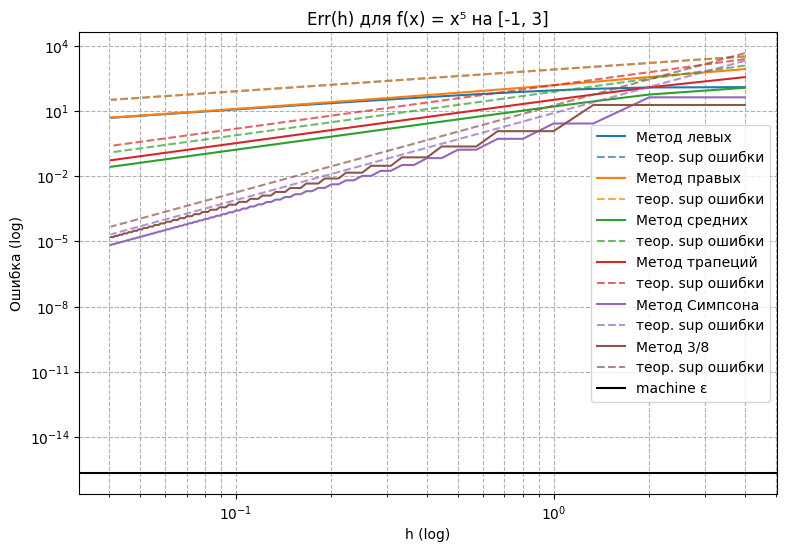

In [13]:
test_h(
  title = "f(x) = x⁵",
  f = lambda x: x**5,
  F = lambda x: x**6/6,
  a = -1,
  b = 3,
  M = {1: 405, 2: 460, 4: 360},
  n_axis = range(1, 100, 1)
)

##### $f(x) = \frac1x$

При отрицательных степенях не происходит ничего интересного, кроме невозможности вычислить интеграл около нуля. Ошибки возрастают при убывании n.

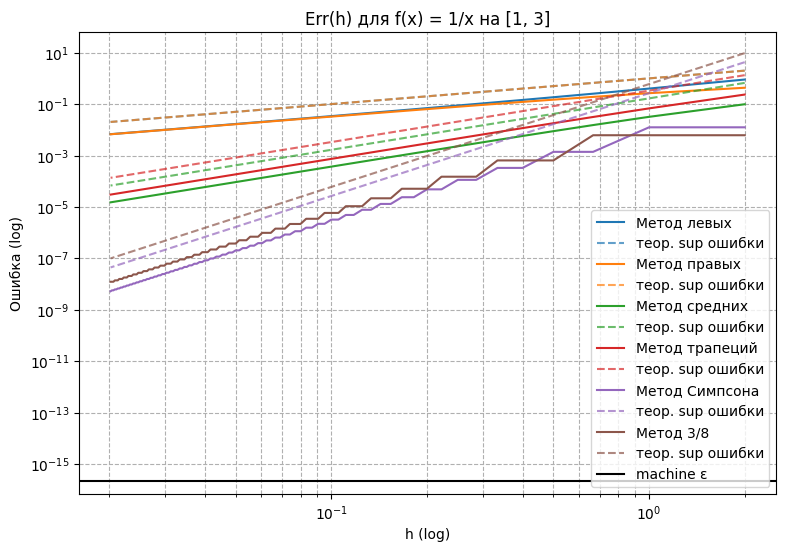

In [14]:
test_h(
  title = "f(x) = 1/x",
  f = lambda x: 1/x,
  F = lambda x: math.log(x),
  a = 1,
  b = 3,
  M = {1: 1, 2: 2, 4: 24},
  n_axis = range(1, 100, 1)
)

##### $f(x) = \frac1{x^2}$

При отрицательных степенях не происходит ничего интересного, кроме невозможности вычислить интеграл около нуля. Ошибки возрастают при убывании n.

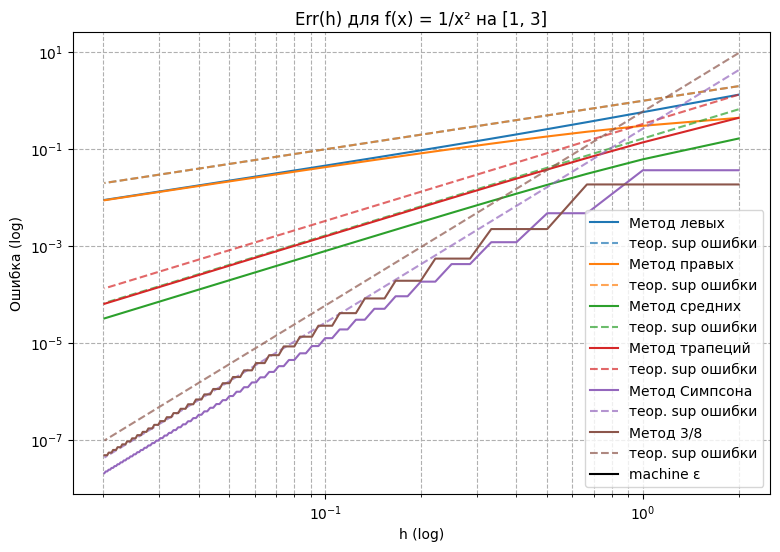

In [15]:
test_h(
  title = "f(x) = 1/x²",
  f = lambda x: x**(-2),
  F = lambda x: x**(-1) / (-1),
  a = 1,
  b = 3,
  M = {1: 1, 2: 2, 4: 24},
  n_axis = range(1, 100, 1)
)

### $f(x) = e^x$

In [16]:
test_simple(
  f = lambda x: math.exp(x),
  F = lambda x: math.exp(x),
  a = -2,
  b = 2,
  n = 100
)

Истинное значение 7.253720815694038
Шаг 0.040
Метод левых:	7.1096135364	(1.98666702%)
Метод правых:	7.3997623690	(2.01333298%)
Метод средних:	7.2532372569	(0.00666636%)
Метод трапеций:	7.2546879527	(0.01333298%)
Метод Симпсона:	7.2537209188	(0.00000142%)
Метод 3/8:	7.2537210301	(0.00000296%)


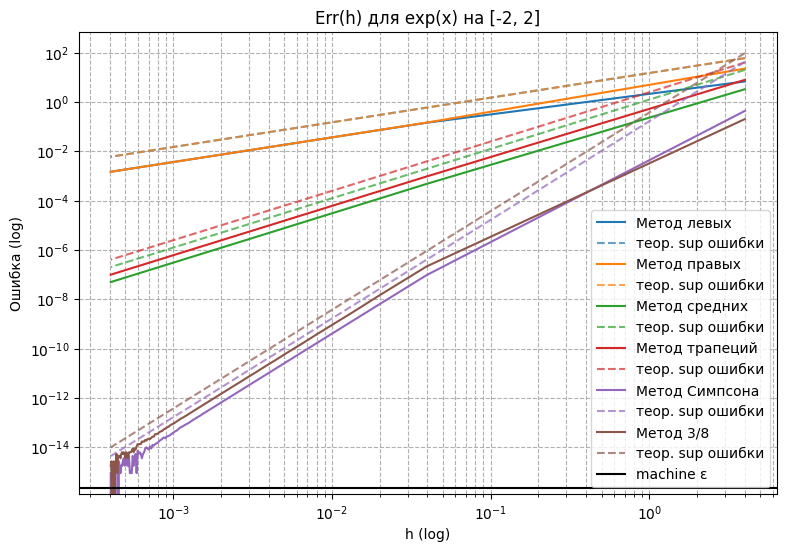

In [17]:
test_h(
  title = "exp(x)",
  f = lambda x: math.exp(x),
  F = lambda x: math.exp(x),
  a = -2,
  b = 2,
  M = {1: math.exp(2), 2: math.exp(2), 4: math.exp(2)},
  n_axis = range(1, 10000, 100)
)

### $f(x) = \sin{x}$

In [18]:
test_simple(
  f = lambda x: math.sin(x),
  F = lambda x: -math.cos(x),
  a = 0,
  b = 1 * math.pi,
  n = 100
)

Истинное значение 2.0
Шаг 0.031
Метод левых:	1.9998355039	(0.00822481%)
Метод правых:	1.9998355039	(0.00822481%)
Метод средних:	2.0000822491	(0.00411245%)
Метод трапеций:	1.9998355039	(0.00822481%)
Метод Симпсона:	2.0000000108	(0.00000054%)
Метод 3/8:	2.0000000225	(0.00000113%)


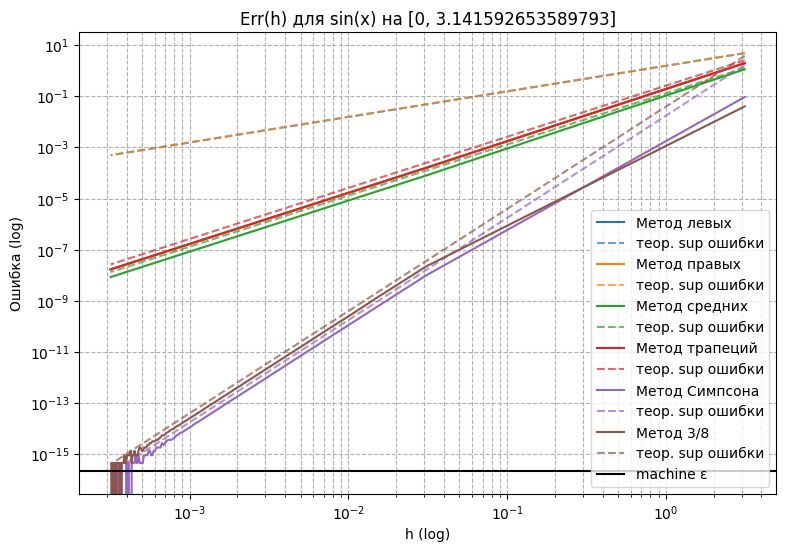

In [19]:
test_h(
  title = "sin(x)",
  f = lambda x: math.sin(x),
  F = lambda x: -math.cos(x),
  a = 0,
  b = math.pi,
  M = {1: 1, 2: 1, 4: 1},
  n_axis = range(1, 10000, 100)
)

Как в синусе, так и в экспоненте ошибка уменьшается, пока не достигает значений, недоступных из-за машинной точности. Реальная ошибка не превосходит оценку сверху.

### Метод Монте-Карло

In [20]:
# Для воспроизводимости результата
np.random.seed(0)

In [21]:
def integrate_monte_carlo(f: ScalarFunc, a: float, b: float, n: int) -> float:
  """ Вычисляет интеграл методом Монте-Карло """
  xs = np.random.uniform(a, b, n)
  return (b - a) * np.average(f(xs))

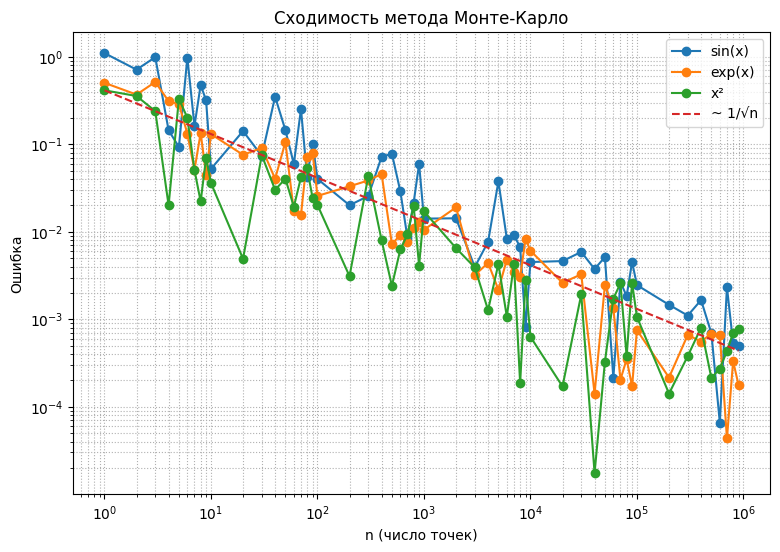

In [22]:
Test = namedtuple('Test' , 'name func a b F')
tests = [
    ("sin(x)", lambda x: np.sin(x), 0, math.pi, lambda x: -np.cos(x)),
    ("exp(x)", lambda x: np.exp(x), 0, 1,       lambda x: np.exp(x)),
    ("x²"    , lambda x: x**2,      0, 1,       lambda x: x**3/3)
]
# Количество точек
n_values = []
for i in range(6):
  n_values.extend(list(range(10**i, 10**(i+1), 10**i)))

# Эксперементы
plt.figure(figsize=(9,6))
for name, f, a, b, F in tests:
    exact = F(b) - F(a)
    errors = []
    for n in n_values:
        estimate = integrate_monte_carlo(f, a, b, n)
        errors.append(abs(estimate - exact))
    plt.plot(n_values, errors, marker="o", label=name)

# Линия сходимости 1/√n
n_ref = np.array(n_values)
err_ref = errors[0] * (n_ref / n_ref[0])**(-0.5)
plt.plot(n_ref, err_ref, linestyle="--", label="~ 1/√n")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("n (число точек)")
plt.ylabel("Ошибка")
plt.title("Сходимость метода Монте-Карло")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.show()

Ошибка в методе ожидаемо уменьшается согласно линии сходимости $\frac1{\sqrt{n}}$.